In [14]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 


In [15]:
dataset = pd.read_csv(r"C:\Users\BAPS\Downloads\FINAL (3)\Churn_Modelling.csv")

In [16]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
X = dataset.iloc[:,3:13]
Y = dataset.iloc[:,13]

In [18]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [19]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [20]:
geography = pd.get_dummies(X['Geography'],drop_first = True).astype(int)
gender = pd.get_dummies(X['Gender'],drop_first=True).astype(int)

In [21]:
X.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [22]:
X = X.drop(['Geography','Gender'],axis=1)

In [23]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [24]:
X = pd.concat([X,geography,gender],axis=1)

In [25]:

X.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Germany', 'Spain', 'Male'],
      dtype='object')

In [26]:
dataset['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0 )

In [28]:
#  Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



In [29]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [30]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [31]:
X_train.shape

(8000, 11)

In [32]:
# CREATE THE ANN 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [33]:
classifier = Sequential()

In [34]:
# Adding the input layer
classifier.add(Dense(units=11,activation='relu'))

In [35]:
# adding the first hiddne layer 
classifier.add(Dense(units=7,activation='relu'))

In [36]:
# adding the second hidden layer 
classifier.add(Dense(units=6,activation='relu'))

In [37]:
# adding the output layer 
classifier.add(Dense(1,activation='sigmoid'))

In [38]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [39]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [42]:
import tensorflow as tf 
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
  
)

In [43]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=550,callbacks=early_stopping)



Epoch 1/550
536/536 [==============================] - 4s 8ms/step - loss: 0.3374 - accuracy: 0.8591 - val_loss: 0.3598 - val_accuracy: 0.8557
Epoch 2/550
536/536 [==============================] - 7s 12ms/step - loss: 0.3352 - accuracy: 0.8621 - val_loss: 0.3583 - val_accuracy: 0.8550
Epoch 3/550
536/536 [==============================] - 5s 10ms/step - loss: 0.3349 - accuracy: 0.8610 - val_loss: 0.3583 - val_accuracy: 0.8535
Epoch 4/550
536/536 [==============================] - 5s 9ms/step - loss: 0.3341 - accuracy: 0.8615 - val_loss: 0.3592 - val_accuracy: 0.8538
Epoch 5/550
536/536 [==============================] - 5s 10ms/step - loss: 0.3335 - accuracy: 0.8604 - val_loss: 0.3611 - val_accuracy: 0.8482
Epoch 6/550
536/536 [==============================] - 5s 10ms/step - loss: 0.3314 - accuracy: 0.8642 - val_loss: 0.3610 - val_accuracy: 0.8504
Epoch 7/550
536/536 [==============================] - 6s 11ms/step - loss: 0.3322 - accuracy: 0.8621 - val_loss: 0.3572 - val_accuracy: 0

In [45]:
model_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

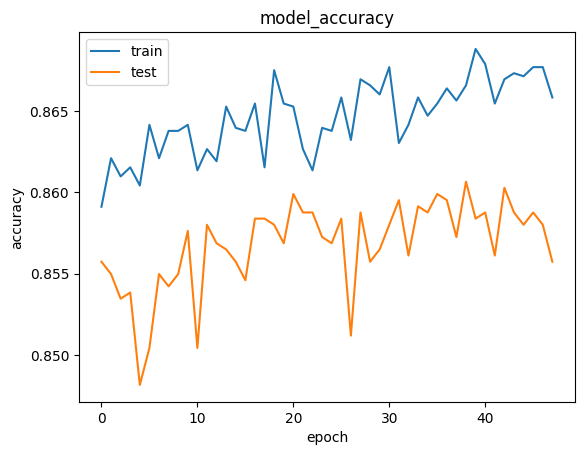

In [46]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

In [47]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 [==============================] - 0s 2ms/step
